### Importing libraries

In [1]:
from HybridCloud import *
import copy
import pandas as pd
import matplotlib.pyplot as plt

### Some helper functions for accounting

In [2]:
def build_job_energy_df(job_records: dict) -> pd.DataFrame:
    rows = []
    for job_id, rec in job_records.items():
        e_qpu = float(rec.get("energy_qpu_kwh", 0.0) or 0.0)
        e_cpu = float(rec.get("energy_cpu_kwh", 0.0) or 0.0)
        e_tot = float(rec.get("energy_total_kwh", e_qpu + e_cpu) or (e_qpu + e_cpu))
        c_tot = float(rec.get("cost_energy_total", 0.0) or 0.0)

        # Avoid divide-by-zero
        if e_tot > 0:
            phi_qpu = e_qpu / e_tot
            phi_cpu = e_cpu / e_tot
        else:
            phi_qpu = 0.0
            phi_cpu = 0.0

        rows.append({
            "job_id": job_id,
            "energy_qpu_kwh": e_qpu,
            "energy_cpu_kwh": e_cpu,
            "energy_total_kwh": e_tot,
            "cost_energy_total": c_tot,
            "phi_qpu": phi_qpu,
            "phi_cpu": phi_cpu,
            "qpu_time_s": float(rec.get("qpu_time_s", 0.0) or 0.0),
            "cpu_time_s": float(rec.get("cpu_time_s", 0.0) or 0.0),
        })

    df = pd.DataFrame(rows).sort_values("job_id").reset_index(drop=True)
    return df

def get_summary(df: pd.DataFrame):
    def p95(x):
        return float(np.percentile(x, 95))

    summary = {
        "number_of_jobs": len(df),

        # ---- Mean energy ----
        "mean_energy_qpu_kwh": df["energy_qpu_kwh"].mean(),
        "mean_energy_cpu_kwh": df["energy_cpu_kwh"].mean(),
        "mean_energy_total_kwh": df["energy_total_kwh"].mean(),

        # ---- Std deviation (energy variability) ----
        "std_energy_qpu_kwh": df["energy_qpu_kwh"].std(),
        "std_energy_cpu_kwh": df["energy_cpu_kwh"].std(),
        "std_energy_total_kwh": df["energy_total_kwh"].std(),

        # ---- Cost statistics ----
        "mean_cost_per_job": df["cost_energy_total"].mean(),
        "median_cost_per_job": df["cost_energy_total"].median(),
        "p95_cost_per_job": p95(df["cost_energy_total"]),

        # ---- Energy fractions ----
        "mean_phi_qpu": df["phi_qpu"].mean(),
        "mean_phi_cpu": df["phi_cpu"].mean(),
    }

    print("\n=== Energy/Cost Summary ===")
    for k, v in summary.items():
        if isinstance(v, float):
            print(f"{k:>22}: {v:.6f}")
        else:
            print(f"{k:>22}: {v}")
    return summary

### Experiment and environment setup

In [3]:
PRINTLOG = False

# -----------------------------
# 0) Devices (create fresh per run recommended)
# -----------------------------
def make_devices(printlog=PRINTLOG):
    # QPUs
    ibm_strasbourg = IBM_Strasbourg(env=None, name="QPU-1", printlog=printlog)
    ibm_brussels   = IBM_Brussels(env=None, name="QPU-2", printlog=printlog)
    # CPUs
    ryzen1 = AMDRyzen("CPU-1", env=None)
    ryzen2 = AMDRyzen("CPU-2", env=None)
    return [ibm_strasbourg, ibm_brussels], [ryzen1, ryzen2]

# -----------------------------
# 1) Base cost_config (we will only update electricity_price_per_kwh)
# -----------------------------
base_cost_config = {
  "energy": {
    "electricity_price_per_kwh": 0.18,  # will be overwritten in sweep
    "default_qpu_power_kw": 50.0,
    "qpu_power_kw": {"QPU-1": 70.0, "QPU-2": 60.0},
    "cpu_power_kw": {"CPU-1": 5.0, "CPU-2": 6.5},
    "cpu_power_model": "affine",
    "default_cpu_idle_kw": 0.22,
    "default_cpu_peak_kw": 0.75,
    "default_cpu_capacity_units": 16,
    "debug_energy": False
  }
}

JOB_CSV = "synth_job_batches/5000-job.csv"

# -----------------------------
# 2) Create env for a run
# -----------------------------
def make_env(cost_config, printlog=PRINTLOG):
    qpus, cpus = make_devices(printlog=printlog)
    sim_env = HybridCloudSimEnv(
        qpu_devices=qpus,
        cpu_devices=cpus,
        broker_class=HybridBroker,
        job_feed_method='dispatcher',
        file_path=JOB_CSV,
        job_generation_model=None,
        printlog=printlog,
        cost_config=cost_config
    )
    return sim_env

# -----------------------------
# 4) Sweep runner
# -----------------------------
def run_price_sweep(prices):
    rows = []

    for p in prices:
        cost_config = copy.deepcopy(base_cost_config)
        cost_config["energy"]["electricity_price_per_kwh"] = float(p)

        sim_env = make_env(cost_config, printlog=PRINTLOG)

        print(f"\n=== Running electricity price: ${p:.2f}/kWh ===")
        # (Optional) sanity prints
        print(f"cpu_power_model: {sim_env.cost_config['energy']['cpu_power_model']}")
        print(f"default_cpu_idle_kw: {sim_env.cost_config['energy']['default_cpu_idle_kw']}")

        sim_env.run()

        job_records = sim_env.job_records_manager.job_records
        df_jobs = build_job_energy_df(job_records)

        # Save one row per price point
        summary = get_summary(df_jobs)
        summary["electricity_price_per_kwh"] = float(p)
        rows.append(summary)

    df_sweep = pd.DataFrame(rows).sort_values("electricity_price_per_kwh").reset_index(drop=True)
    return df_sweep



=== Running electricity price: $0.05/kWh ===
cpu_power_model: affine
default_cpu_idle_kw: 0.22
2 QPU(s), 2 CPU(s)
0.00: SIMULATION STARTED
3227.82: SIMULATION ENDED
Number of jobs processed: 5000

=== Energy/Cost Summary ===
        number_of_jobs: 5000
   mean_energy_qpu_kwh: 0.148563
   mean_energy_cpu_kwh: 0.003301
 mean_energy_total_kwh: 0.151864
    std_energy_qpu_kwh: 0.075417
    std_energy_cpu_kwh: 0.001038
  std_energy_total_kwh: 0.075951
     mean_cost_per_job: 0.007592
   median_cost_per_job: 0.006800
      p95_cost_per_job: 0.014800
          mean_phi_qpu: 0.973640
          mean_phi_cpu: 0.026372

=== Running electricity price: $0.10/kWh ===
cpu_power_model: affine
default_cpu_idle_kw: 0.22
2 QPU(s), 2 CPU(s)
0.00: SIMULATION STARTED
3228.49: SIMULATION ENDED
Number of jobs processed: 5000

=== Energy/Cost Summary ===
        number_of_jobs: 5000
   mean_energy_qpu_kwh: 0.149230
   mean_energy_cpu_kwh: 0.003299
 mean_energy_total_kwh: 0.152528
    std_energy_qpu_kwh: 0.07

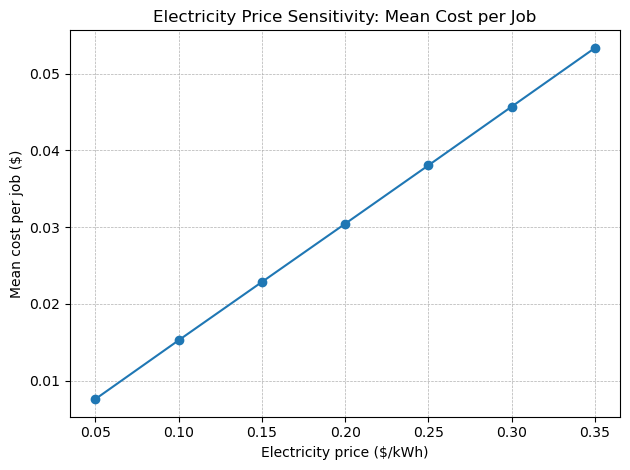

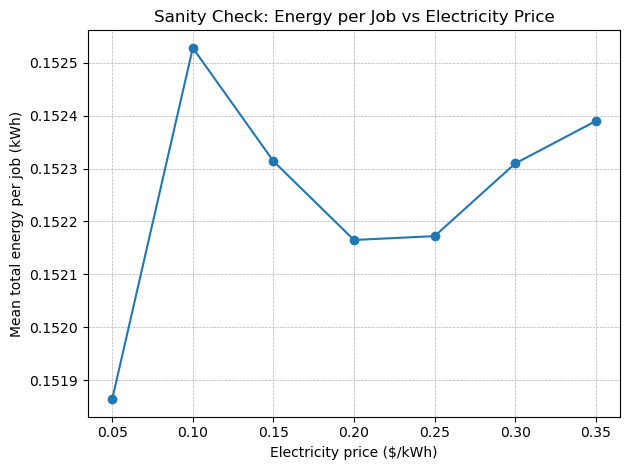

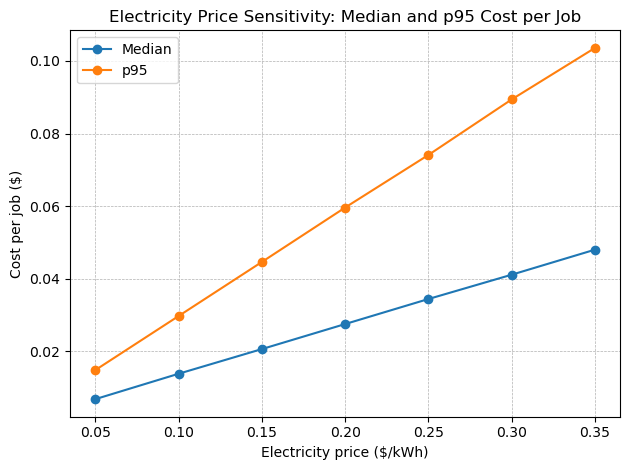

In [4]:
# -----------------------------
# 5) Execute sweep
# -----------------------------

import matplotlib.pyplot as plt

prices = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
df_sweep = run_price_sweep(prices)

df_sweep.to_csv("electricity_price_sensitivity.csv", index=False)
print("\nSaved electricity_price_sensitivity.csv")

# Mean cost per job vs electricity price
plt.figure()
plt.plot(df_sweep["electricity_price_per_kwh"], df_sweep["mean_cost_per_job"], marker="o")
plt.xlabel("Electricity price ($/kWh)")
plt.ylabel("Mean cost per job ($)")
plt.title("Electricity Price Sensitivity: Mean Cost per Job")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("price_vs_mean_cost_per_job.png", dpi=300)

# Sanity check: energy should not change with price
plt.figure()
plt.plot(df_sweep["electricity_price_per_kwh"], df_sweep["mean_energy_total_kwh"], marker="o")
plt.xlabel("Electricity price ($/kWh)")
plt.ylabel("Mean total energy per job (kWh)")
plt.title("Sanity Check: Energy per Job vs Electricity Price")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("price_vs_mean_energy_total_kwh.png", dpi=300)

# Optional: median + p95 curves
plt.figure()
plt.plot(df_sweep["electricity_price_per_kwh"], df_sweep["median_cost_per_job"], marker="o", label="Median")
plt.plot(df_sweep["electricity_price_per_kwh"], df_sweep["p95_cost_per_job"], marker="o", label="p95")
plt.xlabel("Electricity price ($/kWh)")
plt.ylabel("Cost per job ($)")
plt.title("Electricity Price Sensitivity: Median and p95 Cost per Job")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("price_vs_cost_quantiles.png", dpi=300)

plt.show()